In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Lectura del csv con los Primos hasta el 50 millones

In [150]:
df_primos = pd.read_csv('primos.csv')
df_primos.head()

,Primos
0,2
1,3
2,5
3,7
4,11


# 2. Adición de campos donde se ubican los primos en una circunferencia unitaria.

In [151]:
# ================================================================================================
# Campo rest corresponde a la parte decimal de la división entre el número primo y pi. Es decir,
# la ubicación del número primo en el círculo unitario.
# ================================================================================================
df_primos['rest'] = df_primos.Primos.apply(lambda x: int(x) % math.pi)

# ================================================================================================
# A partir de la ubicación del número primo en el círculo unitario, se pueden calcular las coordenadas
# de cada número primo. Estas coordenadas corresponden a los valores de coseno y seno de la parte
# decimal de la división entre el número primo y pi.
# ================================================================================================
df_primos['cos'] = df_primos.rest.apply(lambda x: math.cos(x))
df_primos['sin'] = df_primos.rest.apply(lambda x: math.sin(x))
df_primos.head()

,Primos,rest,cos,sin
0,2,2.000000,-0.416147,0.909297
1,3,3.000000,-0.989992,0.141120
2,5,1.858407,-0.283662,0.958924
3,7,0.716815,0.753902,0.656987
4,11,1.575222,-0.004426,0.999990


In [152]:

# ================================================================================================
# A partir de la ubicación del número primo en el círculo unitario, se puede calcular el área del
# triángulo formado por el origen, el punto en el círculo unitario y el eje x.
# ================================================================================================

df_primos['area'] = (df_primos.cos * df_primos.sin)/2
df_primos.head()

,Primos,rest,cos,sin,area
0,2,2.000000,-0.416147,0.909297,-0.189201
1,3,3.000000,-0.989992,0.141120,-0.069854
2,5,1.858407,-0.283662,0.958924,-0.136005
3,7,0.716815,0.753902,0.656987,0.247652
4,11,1.575222,-0.004426,0.999990,-0.002213


## 2.1. Primo vs Área

(-0.5, 0.5)

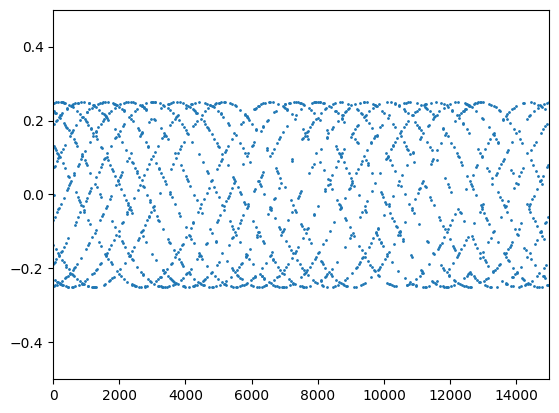

In [153]:
# ================================================================================================
# Scatter del área de los triángulos formados por el origen, el punto en el círculo unitario y el
# eje x, en función del número primo.
# ================================================================================================
plt.scatter(df_primos.Primos, df_primos.area, s = 1)
plt.xlim(0, 15000)
plt.ylim(-0.5, 0.5)